 - Fit a polynomial curve to the vertical compressive data and digitized tensile data
 - Sample the curve
 - Output to csvs
 - Fit in Abaqus

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

from phd_helpers.experiments import get_instron_data

#### Load digitise tensile data

In [42]:
path = Path('../../digitisedData/elasticoKim2024')
csvs = list(path.glob('*.csv'))

dfs = []
for csv in csvs:
    dfs.append(pd.read_csv(csv))

tensile = pd.concat(dfs).reset_index(drop=True)

In [43]:
tensile

,strain,stress
0,0.6469,0.1934
1,0.9473,0.2411
2,1.1880,0.2781
3,1.6020,0.3576
4,2.4630,0.5510
...,...,...
72,3.7980,1.0460
73,3.9520,1.1180
74,4.0790,1.1790
75,4.1990,1.2500


#### Load vertical compressive data

In [45]:
path = Path('../../LabData/materialsTesting/cylinders/elastico/20260427')
csvs = sorted([x for x in path.glob('**/*.csv') if 'V' in x.parent.name])
csvs

[PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/1_1.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/1_2.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/1_3.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/2_1.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/2_2.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/2_3.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/3_1.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/3_2.csv'),
 PosixPath('../../LabData/materialsTesting/cylinders/elastico/20260427/V.is_comp_Exports/3_3.csv')]

In [46]:

F0 = 0.5 # (N) initial seating load
dN = 10 # (mm) total displacement after preload applied

L0 = 20
A0 = np.pi*(5**2) # mm^2

dfs = []
for csv in csvs:
    data_raw = get_instron_data(csv, False)
    data_raw['force'] *= 1e3 # convert from kN to N
    data = data_raw[data_raw['force'] >= F0] # get data after initial load
    data['displacement'] -= data['displacement'].min() # reset displacement
    data['force'] -= data['force'].min() # reset force
    data = data[data['displacement'] <= dN] # clip excess

    data['strain'] = - data['displacement'] / L0
    data['stress'] = - data['force'] / A0 # MPa

    dfs.append(data[['stress', 'strain']])
        
compressive = pd.concat(dfs).reset_index(drop=True)

In [47]:
compressive

,stress,strain
0,-0.000000,-0.000000
1,-0.000000,-0.000020
2,-0.000000,-0.000035
3,-0.000000,-0.000125
4,-0.000000,-0.000145
...,...,...
269975,-0.632800,-0.499925
269976,-0.632800,-0.499940
269977,-0.634073,-0.499960
269978,-0.634073,-0.499975


#### Fit curves to compressive and tensile separately, sample them, fit one curve to sampled data, then sample that curve

In [49]:
def polyfit(x, y, degree, intercept=True):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    start = 0 if intercept else 1
    X = np.column_stack([x**k for k in range(start, degree + 1)])

    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef

def polyval(coef, x, intercept=True):
    x = np.asarray(x)
    start = 0 if intercept else 1
    yhat = np.zeros_like(x, dtype=float)
    for k, a in enumerate(coef, start=start):
        yhat += a * x**k
    return yhat

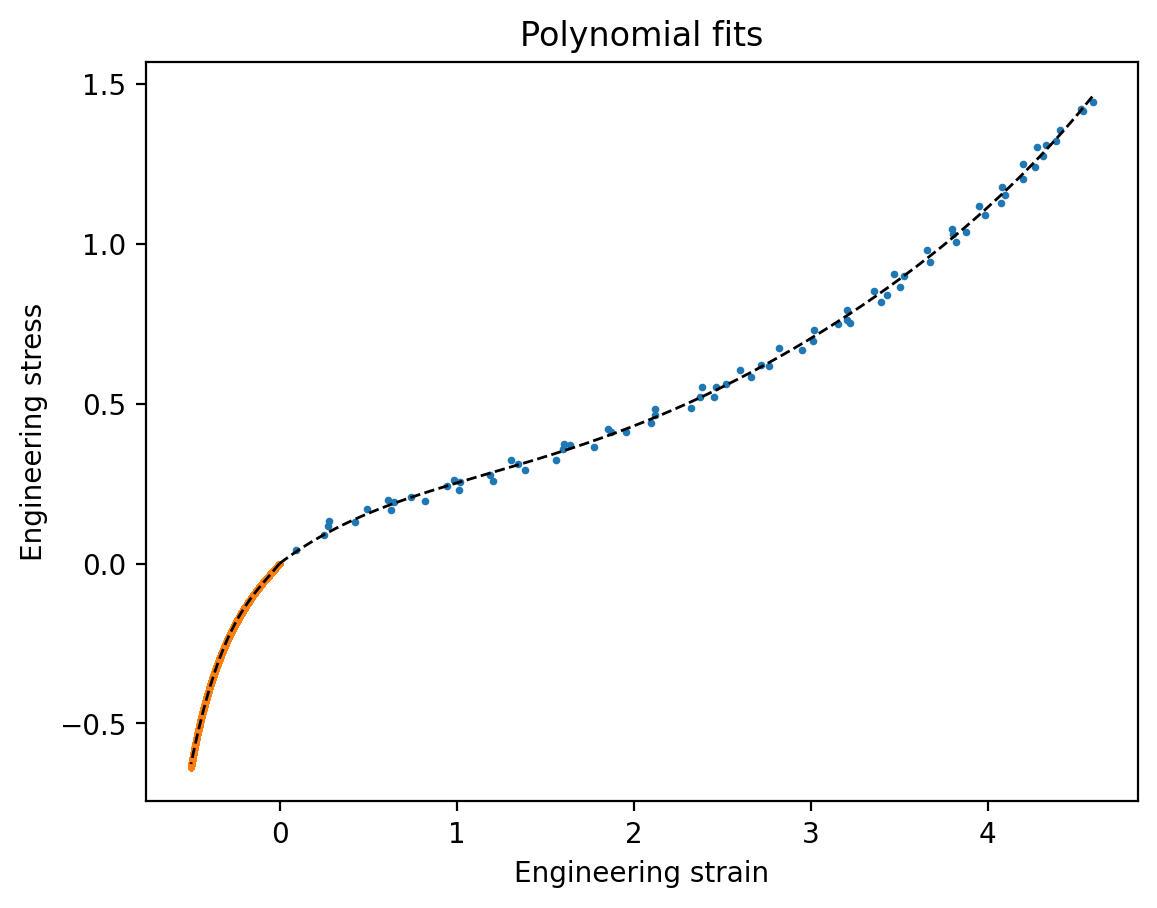

In [91]:
fig, ax = plt.subplots(dpi=200)

p = 5
tensile_coef = polyfit(tensile['strain'], tensile['stress'], p, False)
xs = np.linspace(0, max(tensile['strain']), 500)
ys = polyval(tensile_coef, xs, False)
ax.scatter(tensile['strain'], tensile['stress'], s=3)
ax.plot(xs, ys, linewidth=1, c='black', linestyle='--')

p = 3
compressive_coef = polyfit(compressive['strain'], compressive['stress'], p, False)
xs = np.linspace(0, min(compressive['strain']), 500)
ys = polyval(compressive_coef, xs, False)
ax.scatter(compressive['strain'], compressive['stress'], s=1)
ax.plot(xs, ys, linewidth=1, c='black', linestyle='--')

ax.set_title('Polynomial fits')
ax.set_xlabel('Engineering strain')
ax.set_ylabel('Engineering stress')
plt.show()

In [ ]:
# evenly distributed along both curves ?? (or same number of samples from each curve?)
step = 0.01
compressive_strain_sample = np.arange(min(compressive['strain']), 0+step, step)
tensile_strain_sample = np.arange(0, max(tensile['strain'])+step, step)

In [93]:
# same number of samples from each curve
n = 101
compressive_strain_sample = np.linspace(min(compressive['strain']), 0, n)
tensile_strain_sample = np.linspace(0, max(tensile['strain']), n)

compressive_stress_sample = polyval(compressive_coef, compressive_strain_sample, False)
tensile_stress_sample = polyval(tensile_coef, tensile_strain_sample, False)

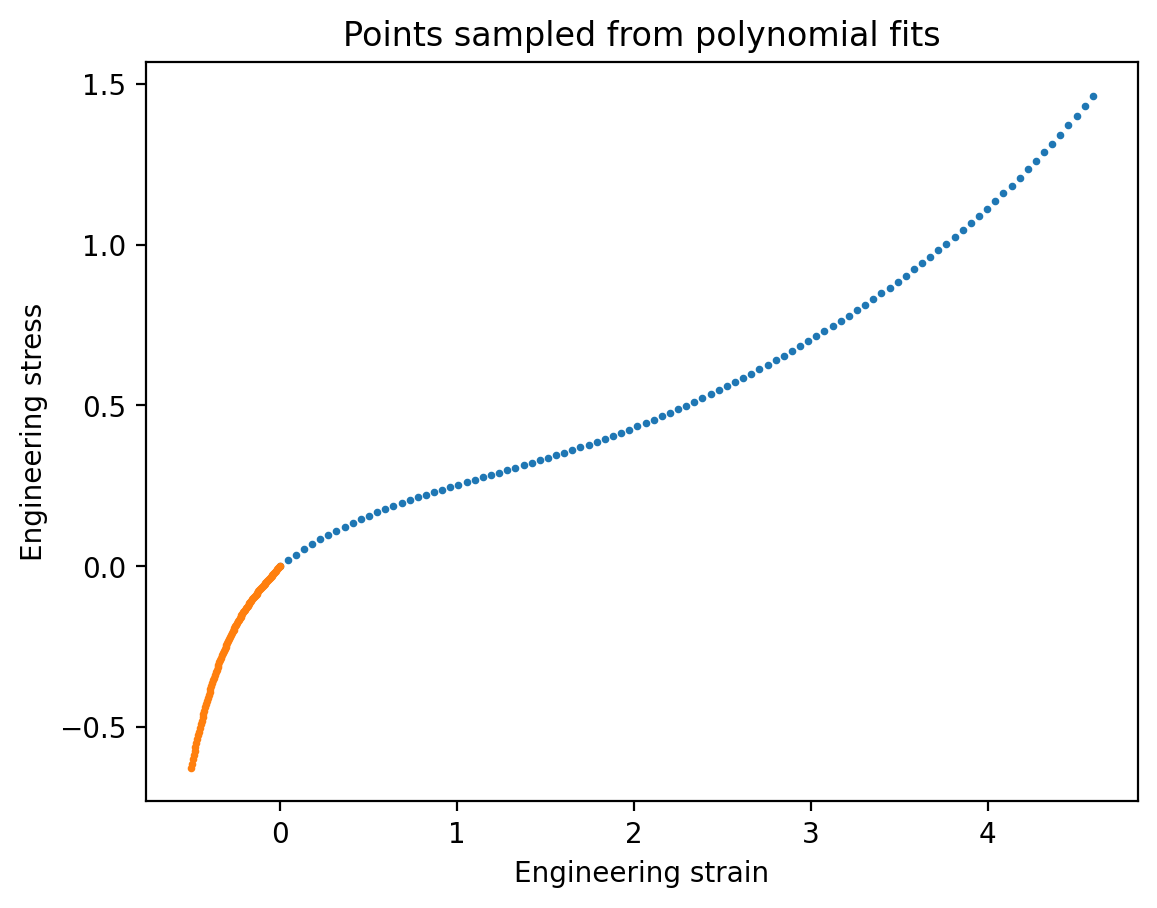

In [94]:
fig, ax = plt.subplots(dpi=200)

ax.scatter(tensile_strain_sample, tensile_stress_sample, s=3)
ax.scatter(compressive_strain_sample, compressive_stress_sample, s=3)

ax.set_title('Points sampled from polynomial fits')
ax.set_xlabel('Engineering strain')
ax.set_ylabel('Engineering stress')
plt.show()

In [100]:
strain = np.hstack((compressive_strain_sample, tensile_strain_sample))
stress = np.hstack((compressive_stress_sample, tensile_stress_sample))
df = pd.DataFrame({'stress': stress, 'strain': strain})
df

,stress,strain
0,-0.626986,-0.50000
1,-0.613568,-0.49500
2,-0.600381,-0.49000
3,-0.587420,-0.48500
4,-0.574685,-0.48000
...,...,...
197,1.342780,4.40928
198,1.371649,4.45521
199,1.401293,4.50114
200,1.431750,4.54707


#### Save sampled points

In [101]:
out_path = Path('elasticoData4abaqus')
out_path.mkdir(exist_ok=True)

df['stress'].to_csv(out_path / 'stress.csv', index=False, header=False)
df['strain'].to_csv(out_path / 'strain.csv', index=False, header=False)

#### Results from passing sampled data to abaqus
- the following were stable accross all strains (except ogden)

In [ ]:
fit_error = {
    'ogden_n=3': 0.6086,
    'mooney-rivlin_n=1': 3.935,
    'neo-hookean': 4.165,
    'yeoh': 1.880
}

# yeoh is stable for all strains and looks like a reasonably good fit
yeoh = {
    'C10': 8.803801176e-2,
    'C20': -1.296223053e-3,
    'C30': 5.420005435e-5
}
# for nu=0.493 (from video analysis), D1 = 0.159767802 ( coefs didn't change )